In [1]:
from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')

In [1]:
import pybinding as pb
import matplotlib.pyplot as plt
import numpy as np

from pybinding.repository import graphene

import os.path

from matplotlib.patches import Rectangle

import matplotlib.gridspec as gridspec

dataDirRoot = "/Users/nihao/Dropbox/nonSharedProjectsFolders/BilayerAndTrilayerRibbons/dataDir/"

In [2]:
def bilayer_graphene():
    """Bilayer lattice in the AB-stacked form (Bernal-stacked)"""
    lat = pb.Lattice(a1=[graphene.a, 0], a2=[0.5*graphene.a, 0.5*np.sqrt(3)*graphene.a])

    c0 = 0.335  # [nm] interlayer spacing
    lat.add_sublattices(('A1', [0,  -graphene.a_cc/2,   0]),
                        ('B1', [0,   graphene.a_cc/2,   0]),
                        ('A2', [0,   graphene.a_cc/2, -c0]),
                        ('B2', [0, 3*graphene.a_cc/2, -c0]))
    lat.register_hopping_energies({'t': graphene.t, 't_layer': -0.4})
    lat.add_hoppings(
        # layer 1
        ([ 0,  0], 'A1', 'B1', 't'),
        ([ 1, -1], 'A1', 'B1', 't'),
        ([ 0, -1], 'A1', 'B1', 't'),
        # layer 2
        ([ 0,  0], 'A2', 'B2', 't'),
        ([ 1, -1], 'A2', 'B2', 't'),
        ([ 0, -1], 'A2', 'B2', 't'),
        # interlayer
        ([ 0,  0], 'B1', 'A2', 't_layer'),
        #([0, -1], 'A1', 'A2', 0.138), # diagonal blue green
        #([0, -1], 'B1', 'B2', 0.138), # diagonal orange red
        #([0, 2], 'B2', 'A1', 0.283), # super diagonal blue red
        
    )
    lat.min_neighbors = 2
    return lat

In [3]:
def bilayer_graphene_armchair():
        """Bilayer lattice in the AB-stacked form (Bernal-stacked)"""
        c0 = 0.335  # [nm] interlayer spacing
        ac = graphene.a_cc
        
        lat = pb.Lattice(a1=[3*ac, 0], a2=[0, graphene.a])

        
        lat.add_sublattices(('1', [-ac/2,np.sqrt(3)*ac/2,   0]),
                            ('2', [0,   0,   0]),
                            ('3',[ac,0,0]),
                            ('4',[3*ac/2,np.sqrt(3)*ac/2,0]),
                            ('5', [-ac/2,np.sqrt(3)*ac/2,  -c0]),
                            ('6', [ac/2,np.sqrt(3)*ac/2, -c0]),
                            ('7',[ac,0,-c0]),
                            ('8',[2*ac,0,-c0]))
        lat.register_hopping_energies({'t': graphene.t, 't_layer': -0.4})
        lat.add_hoppings(
         #layer 1
           ([ 0,  0], '1', '2', 't'),
           ([ 0,  0], '2', '3', 't'),
           ([ 0,  0], '3', '4', 't'), 
           ([ 0,  1], '1', '2', 't'),
           ([ 0,  1], '4', '3', 't'), 
           ([ 1,  0], '4', '1', 't'), 
           
        # layer 2
           ([ 0,  0], '5', '6', 't'),
           ([ 0,  0], '6', '7', 't'),
           ([ 0,  0], '7', '8', 't'),
           ([ 0,  -1], '7', '6', 't'),
           ([ 1,  0], '8', '5', 't'),
           ([ 1,  -1], '8', '5', 't'), 
        # interlayer
           ([ 0,  0], '1', '5', 't_layer'),
           ([ 0,  0], '3', '7', 't_layer') 
        )
        lat.min_neighbors = 2
        return lat
    
ac = graphene.a_cc

In [4]:
## Add a triangular moire potential in the bottom layer only - H0
def moire_pattern_Jeil_H0(C0, phi0, epsilon):
    a = graphene.a
    G1 = 4.0*np.pi/np.sqrt(3.0)/a
    @pb.onsite_energy_modifier
    def potential(energy, x, y, sub_id):
        dx = epsilon*x
        dy = epsilon*y
        fd = np.exp(-1J*G1*dy) + 2.0*np.exp(1J*G1*dy/2.0) * np.cos(np.sqrt(3.0)/2*G1*dx)
        ymax = np.max(y)
        H0 = 2.0*C0*(fd*np.exp(1J*phi0)).real
        if (sub_id == 'A1'):
            energy[sub_id == 'A1'] += H0
        if (sub_id == 'B1'):    
            energy[sub_id == 'B1'] += H0
        if (sub_id == 'A2'):
            energy[sub_id == 'A2'] += H0
        if (sub_id == 'B2'):    
            energy[sub_id == 'B2'] += H0
        return energy
    return potential

## Add a triangular moire potential in the bottom layer only - HZ
def moire_pattern_Jeil_HZ(C0, phi0, epsilon):
    a = graphene.a
    G1 = 4.0*np.pi/np.sqrt(3.0)/a
    @pb.onsite_energy_modifier
    def potential(energy, x, y, sub_id):
        dx = epsilon*x
        dy = epsilon*y
        fd = np.exp(-1J*G1*dy) + 2.0*np.exp(1J*G1*dy/2.0) * np.cos(np.sqrt(3.0)/2*G1*dx)
        ymax = np.max(y)
        HZ = 2.0*C0*(fd*np.exp(1J*phi0)).real
        if (sub_id == 'A1'):
            energy[sub_id == 'A1'] += HZ
        if (sub_id == 'B1'):    
            energy[sub_id == 'B1'] -= HZ
        return energy
    return potential

## Double the strength of the potential in the center of the ribbon
def moire_modulate(factor,nMoire):
    @pb.onsite_energy_modifier
    def potential(energy, x, y, sub_id):
        ymax = np.max(y)
        energy[y<-ymax/nMoire*2] *= 1
        energy[np.logical_and(y<0,y>-ymax/nMoire*2)] *= factor
        energy[np.logical_and(y<ymax/nMoire*2,y>0)] *= factor
        energy[(y>ymax/nMoire*2)] *= 1
        #print(energy)
        return energy
    return potential

def moire_modulate_kink(factor,nMoire):
    @pb.onsite_energy_modifier
    def potential(energy, x, y, sub_id):
        ymax = np.max(y)
        energy[y<-ymax/nMoire*2] *= factor
        energy[np.logical_and(y<0,y>-ymax/nMoire*2)] *= factor
        energy[np.logical_and(y<ymax/nMoire*2,y>0)] *= -factor
        energy[(y>ymax/nMoire*2)] *= -factor
        #print(energy)
        return energy
    return potential

def moire_modulate_E(factor,nMoire):
    @pb.onsite_energy_modifier
    def potential(energy, x, y, sub_id):
        ymax = np.max(y)
        energy[y<-ymax/nMoire*2] *= 1
        energy[np.logical_and(y<0,y>-ymax/nMoire*2)] *= factor
        energy[np.logical_and(y<ymax/nMoire*2,y>0)] *= factor
        energy[(y>ymax/nMoire*2)] *= 1
        #print(energy)
        return energy
    return potential

## Add an electric field
def electric_field(deltaV):
    """Add an electric field"""
    @pb.onsite_energy_modifier
    def potential(energy, z, sub_id):
        #print(sub_id, z)
        #energy[(sub_id=='A1')] += deltaV
        energy[z<-0.1] -= deltaV/2.0
        energy[z>=-0.1] += deltaV/2.0
        #print(energy)
        return energy
    return potential

def moire1D_0(nPeriods,epsilon,sinAmp):
    @pb.onsite_energy_modifier
    def potential(energy,y,sub_id):
        dy = epsilon*y
        ymax = np.max(y)
        #y = y/ymax 
        #print(y)
        if (sub_id == 'A1'):
            energy[sub_id == 'A1'] += np.sin(nPeriods*np.pi*y/ymax)*sinAmp
        if (sub_id == 'B1'):    
            energy[sub_id == 'B1'] += np.sin(nPeriods*np.pi*y/ymax)*sinAmp
        return energy
    return potential

def moire1D_0_old(nPeriods,epsilon):
    @pb.onsite_energy_modifier
    def potential(energy,y,sub_id):
        dy = epsilon*y
        if (sub_id == 'A1'):
            energy[sub_id == 'A1'] += np.sin(y)*0.01
        if (sub_id == 'B1'):    
            energy[sub_id == 'B1'] += np.sin(y)*0.01
        return energy
    return potential

def moire1D_Z(nPeriods,epsilon,sinAmp):
    @pb.onsite_energy_modifier
    def potential(energy,y,sub_id):
        #dy = epsilon*y
        ymax = np.max(y)
        #y = y/ymax 
        #print(y)
        if (sub_id == 'A1'):
            energy[sub_id == 'A1'] += np.sin(nPeriods*np.pi*y/ymax)*sinAmp
        if (sub_id == 'B1'):    
            energy[sub_id == 'B1'] -= np.sin(nPeriods*np.pi*y/ymax)*sinAmp
        return energy
    return potential

def checkData(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, left, rightK, stepK ):
    os.chdir(dataDir)

    if os.path.exists(fname):
        print(fname, " exists.")
        data = pb.load(fname)
        return data
    else:
        return False
    
def checkData2(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, left, rightK, stepK ):
    os.chdir(dataDir)

    if os.path.exists(fname):
        print(fname, " exists.")
        data = pb.load(fname)
        return data
    else:
        return False
    
def checkData3(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, left, rightK, stepK, bandNr ):
    os.chdir(dataDir)

    if os.path.exists(fname):
        print(fname, " exists.")
        data = pb.load(fname)
        return data
    else:
        return False
    
def makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK):
    return ("DOS_E_" + str(eField) + "_CS_" + str(cellSize) + "_nMx_" + str(nMoireX) + 
         "_nMy_" + str(nMoireY) + "_" + str(Hx) + "_"+ str(Cx )+ "_modF_" + str(modFactor) + "_Ks_" + str(leftK) + "_"
           + str("%.2f" % rightK) + "_stepK_" + str(stepK))

def makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK):
    return ("Bands_E_" + str(eField) + "_CS_" + str(cellSize) + "_nMx_" + str(nMoireX) + 
         "_nMy_" + str(nMoireY) + "_" + str(Hx) + "_"+ str(Cx )+ "_modF_" + str(modFactor) + "_Ks_" + str(leftK) + "_"
           + str("%.2f" % rightK) + "_stepK_" + str(stepK))

def makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr):
    return ("Prob_E_" + str(eField) + "_CS_" + str(cellSize) + "_nMx_" + str(nMoireX) + 
         "_nMy_" + str(nMoireY) + "_" + str(Hx) + "_"+ str(Cx )+ "_modF_" + str(modFactor) + "_Ks_" + str(leftK) + "_"
           + str("%.2f" % rightK) + "_stepK_" + str(stepK) + "_bandNR_" + str(bandNr))

def calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK):
    dos = checkData(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
    if (dos == False):
        dos = kpm.calc_dos(energy=np.linspace(-0.3, 0.3, 500), broadening=0.006, num_random=16)
        pb.save(dos, fname)
    return dos

def calc_bands_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK):
    bands = checkData2(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
    if (bands == False):
        bands = solver.calc_bands(leftK, rightK, step=stepK)
        pb.save(bands, fname)
    return bands

def calc_prob_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr):
    prob = checkData3(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
    if (prob == False):
        solver.set_wave_vector(rightK)
        prob = solver.calc_probability(bandNr)
        pb.save(prob, fname)
    return prob
    
    

/Users/nihao/anaconda/envs/py36/lib/python3.6/site-packages/matplotlib/contour.py:960: UserWarning: The following kwargs were not used by contour: 'rasterized'
  s)


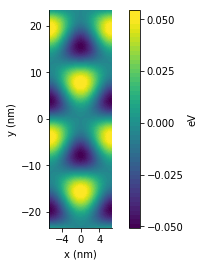

In [13]:
eField = 0.1
cellSize = 55
nMoire = 4
nMoireX = 1
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.3

#plt.figure(figsize=(8,40))

model1 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    moire_pattern_Jeil_H0(C0, phi0, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene(),
    #pb.rectangle(cellSize*3*ac/2,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),m # nm
    pb.rectangle(cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),
    pb.translational_symmetry(a1=3*ac*cellSize*100, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    #moire_pattern_Jeil_H0(C0, phi0, epsilon),
    moire_pattern_Jeil_H0(C0, phi0, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

#smap = model1.structure_map(model1.system.energy)
model2.onsite_map.plot_contourf(vmin=-0.05, vmax=0.05)
#model2.onsite_map.plot()

cbar = plt.colorbar(ticks=[-0.05, -0.025, 0, 0.025, 0.05])
cbar.set_label('eV')

plt.xticks([-4, 0, 4])

#smap.plot_contourf()

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("BilayerZigZagRealSpace.png", dpi=400)

In [8]:
eField = 0.2
cellSize = 30
nMoireX = 10
nMoireY = 4
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
modFactor = 1

model2 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoireX*cellSize*graphene.a*10,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

dataDir = dataDirRoot + "playGround/"

kpm = pb.kpm(model2)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, modFactor)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, modFactor)
dos.plot(label="not modulated")

TypeError: makeName() missing 4 required positional arguments: 'modFactor', 'leftK', 'rightK', and 'stepK'

Bands_E_0.2_CS_1_nMx_1_nMy_1_HZ_0.0_modF_1_Ks_-7.374630642229563_7.37_stepK_0.1  exists.


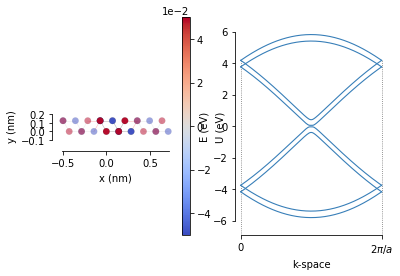

In [22]:
## without kink

ac = graphene.a_cc

eField = 0.2
cellSize = 1
nMoireX = 1
nMoireY = 1
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.0
modFactor = 1


model = pb.Model(
    bilayer_graphene_armchair(),
    #pb.rectangle(4*cellSize*graphene.a,4*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(0.1),
    #moire_pattern_Jeil_HZ(C0, phi0, epsilon),
    #moire_modulate_sign(-1)
    #moire1D_0_old(3,epsilon)
)

dataDir = dataDirRoot + "playGround/"

plt.figure()
plt.subplot(121)
model.onsite_map.plot(cmap="coolwarm", site_radius=0.04)
pb.pltutils.colorbar(label="U (eV)")

solver = pb.solver.lapack(model)

#leftK = 0*np.pi/graphene.a/4
#rightK = 2*np.pi/graphene.a

leftK = -np.pi/(3*ac*cellSize)
rightK = np.pi/(3*ac*cellSize)

plt.subplot(122)
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"0", r"$2 \pi / a$"])
#plt.ylim(-0.2,0.2)

# Publication figures

## Sinus potential

Bands_E_0_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_1_Ks_-7.374630642229563_7.37_stepK_0.01  exists.


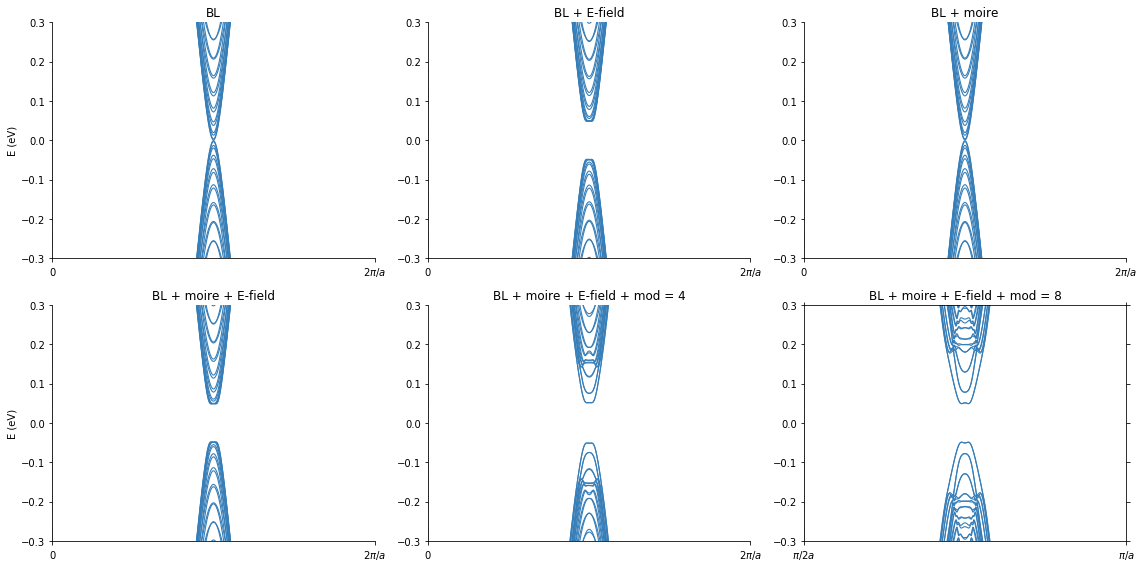

In [5]:
eField = 0.1
cellSize = 40
nMoire = 4
nMoireX = 1
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.2

model = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire1D_Z(3,epsilon,Cx),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    moire1D_Z(3,epsilon,Cx)
    
)

model4 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(8,nMoire),
    moire1D_Z(3,epsilon,Cx),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

#leftK = 0
#rightK = 2*np.pi/graphene.a

leftK = -np.pi/(3*ac)
rightK = np.pi/(3*ac)

yMin = -0.3
yMax = 0.3
xMin = leftK
xMax = rightK
stepK = 0.01

dataDir = dataDirRoot + "SinusPotArmChair/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(231)
solver = pb.solver.lapack(model)
eField = 0
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL")
plt.xlabel("")

plt.subplot(232)
solver0 = pb.solver.lapack(model0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver0, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(233)
solver1 = pb.solver.lapack(model1)
eField = 0
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver1, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(234)
solver2 = pb.solver.lapack(model2)
eField = 0.1
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver2, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(235)
solver3 = pb.solver.lapack(model3)
eField = 0.1
Hx = "HZ"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver3, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx,modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(236)
solver4 = pb.solver.lapack(model4)
eField = 0.1
Hx = "HZ"
modFactor = 8
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver4, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout()

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("SinusCellSize40_Armchair.png", dpi=400)

Bands_E_0_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_1_Ks_-7.374630642229563_7.37_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_1_Ks_-7.374630642229563_7.37_stepK_0.01  exists.
Bands_E_0_CS_40_nMx_1_nMy_4_HZ_0.2_modF_1_Ks_-7.374630642229563_7.37_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_HZ_0.2_modF_1_Ks_-7.374630642229563_7.37_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_HZ_0.2_modF_4_Ks_-7.374630642229563_7.37_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_4_Ks_-7.374630642229563_7.37_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_Min1Bis_Ks_-7.374630642229563_7.37_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_HZ_0.2_modF_Min1Bis_Ks_-7.374630642229563_7.37_stepK_0.01  exists.


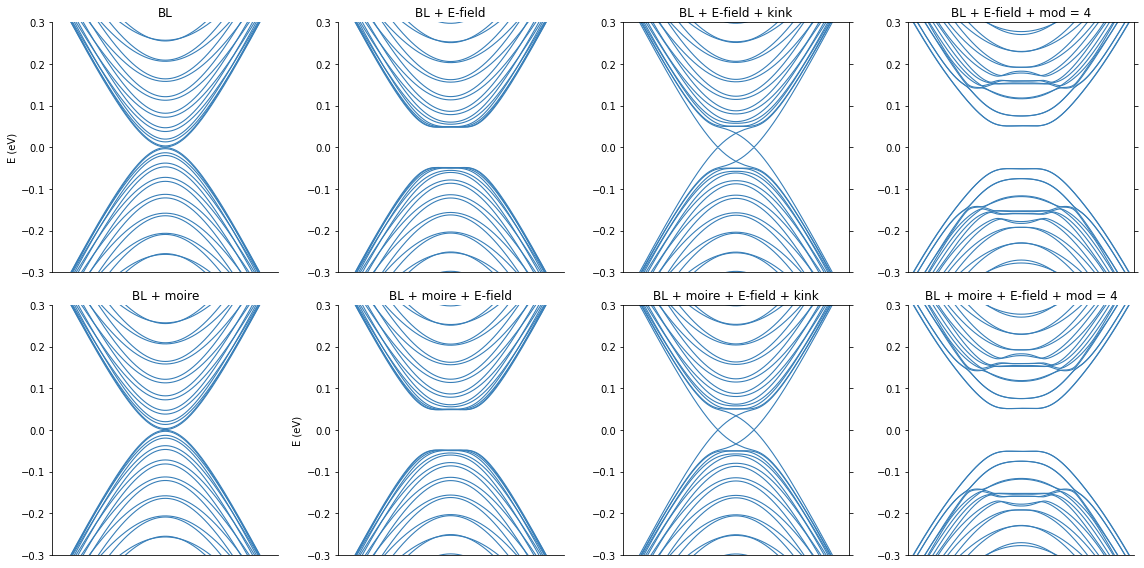

In [5]:
eField = 0.1
cellSize = 40
nMoire = 4
nMoireX = 1
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.2

model = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire1D_Z(3,epsilon,Cx),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    moire1D_Z(3,epsilon,Cx)
    
)

model4 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    moire1D_Z(3,epsilon,Cx),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

leftK = -np.pi/(3*ac)
rightK = np.pi/(3*ac)

yMin = -0.3
yMax = 0.3
xMin = leftK/8
xMax = rightK/8
stepK = 0.01


dataDir = dataDirRoot + "SinusPotArmchair/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)
solver = pb.solver.lapack(model)
eField = 0
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.lapack(model0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver0, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.lapack(model1)
eField = 0
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver1, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.lapack(model2)
eField = 0.1
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver2, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.lapack(model3)
eField = 0.1
Hx = "HZ"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver3, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx,modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.lapack(model4)
eField = 0.1
Hx = "noMoire"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver4, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.lapack(model5)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver5, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.lapack(model6)
eField = 0.1
Hx = "HZ"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver6, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout()

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("SinusCellSize40Armchair.png", dpi=400)

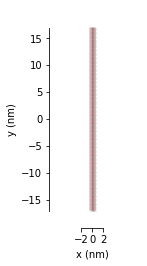

In [6]:
model.plot(num_periods=1)

Bands_E_0_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_1_Ks_-7.374630642229563_7.37_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_1_Ks_-7.374630642229563_7.37_stepK_0.01  exists.
Bands_E_0_CS_40_nMx_1_nMy_4_HZ_0.2_modF_1_Ks_-7.374630642229563_7.37_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_HZ_0.2_modF_1_Ks_-7.374630642229563_7.37_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_HZ_0.2_modF_0.5_Ks_-7.374630642229563_7.37_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_0.5_Ks_-7.374630642229563_7.37_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_Min1Bis_Ks_-7.374630642229563_7.37_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_HZ_0.2_modF_Min1Bis_Ks_-7.374630642229563_7.37_stepK_0.01  exists.


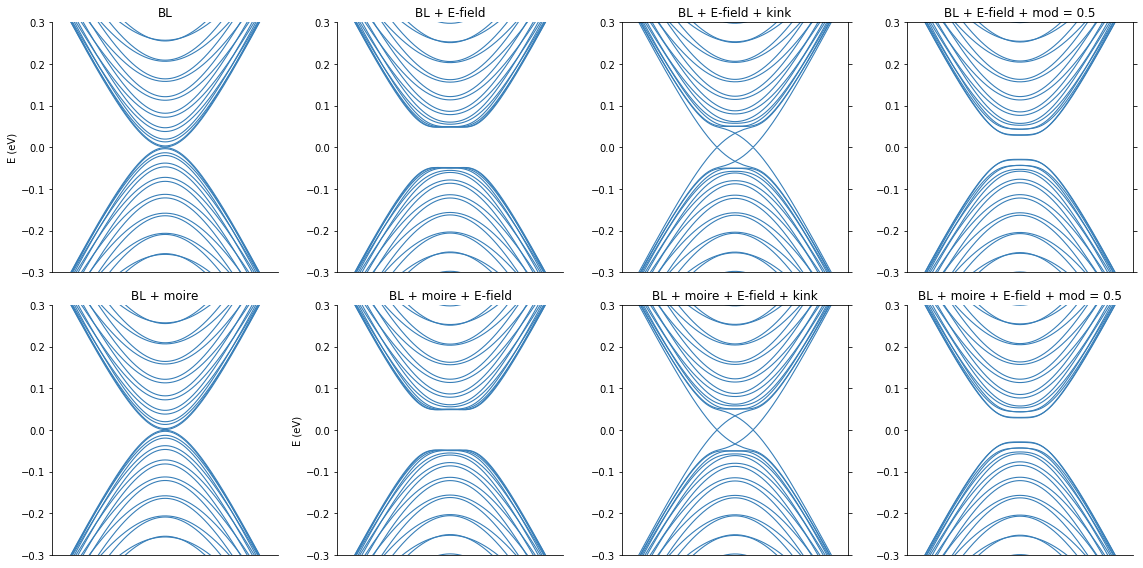

In [20]:
eField = 0.1
cellSize = 40
nMoire = 4
nMoireX = 1
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.2

model = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire1D_Z(3,epsilon,Cx),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(0.5,nMoire),
    moire1D_Z(3,epsilon,Cx)
    
)

model4 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(0.5,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    moire1D_Z(3,epsilon,Cx),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()


leftK = -np.pi/(3*ac)
rightK = np.pi/(3*ac)

yMin = -0.3
yMax = 0.3
xMin = leftK/8
xMax = rightK/8
stepK = 0.01

dataDir = dataDirRoot + "SinusPot/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)
solver = pb.solver.lapack(model)
eField = 0
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.lapack(model0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver0, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.lapack(model1)
eField = 0
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver1, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.lapack(model2)
eField = 0.1
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver2, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.lapack(model3)
eField = 0.1
Hx = "HZ"
modFactor = 0.5
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver3, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx,modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.lapack(model4)
eField = 0.1
Hx = "noMoire"
modFactor = 0.5
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver4, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.lapack(model5)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver5, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.lapack(model6)
eField = 0.1
Hx = "HZ"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver6, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout()

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("SinusCellSize40_Mod0_5.png", dpi=400)

321
Prob_E_0_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_1_Ks_0_25.55_stepK_0.05_bandNR_321  exists.
Prob_E_0.1_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_1_Ks_0_25.55_stepK_0.05_bandNR_321  exists.
Prob_E_0_CS_40_nMx_1_nMy_4_HZ_0.2_modF_1_Ks_0_25.55_stepK_0.05_bandNR_321  exists.
Prob_E_0.1_CS_40_nMx_1_nMy_4_HZ_0.2_modF_1_Ks_0_25.55_stepK_0.05_bandNR_321  exists.
Prob_E_0.1_CS_40_nMx_1_nMy_4_HZ_0.2_modF_4_Ks_0_25.55_stepK_0.05_bandNR_321  exists.
Prob_E_0.1_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_4_Ks_0_25.55_stepK_0.05_bandNR_321  exists.
Prob_E_0.1_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_Min1_Ks_0_25.55_stepK_0.05_bandNR_321  exists.
Prob_E_0.1_CS_40_nMx_1_nMy_4_HZ_0.2_modF_Min1_Ks_0_25.55_stepK_0.05_bandNR_321  exists.


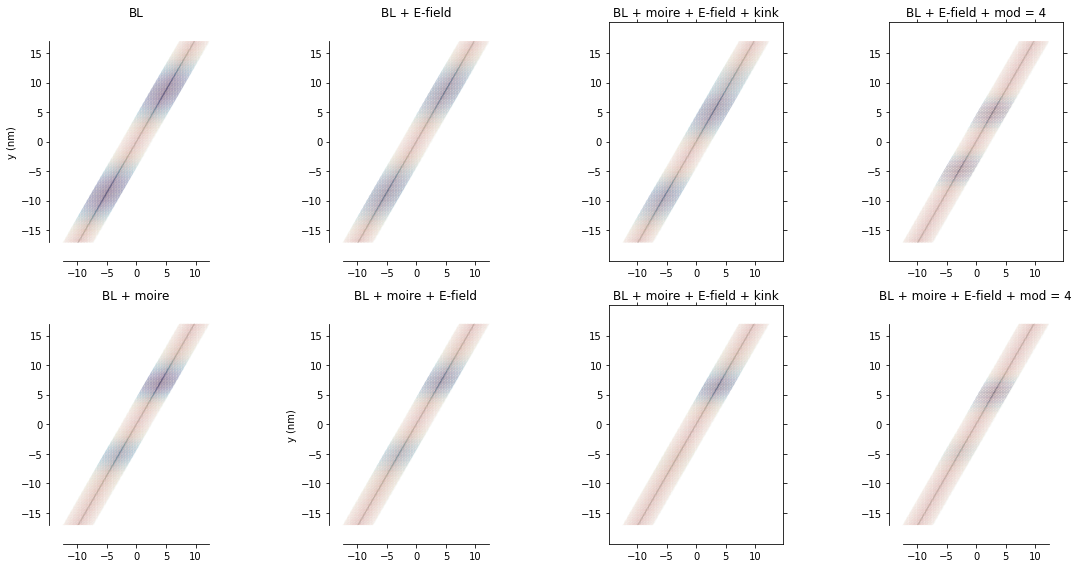

In [11]:
eField = 0.1
cellSize = 40
nMoire = 4
nMoireX = 1
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.2

model = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire1D_Z(3,epsilon,Cx),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    moire1D_Z(3,epsilon,Cx)
    
)

model4 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(-1,4),
    moire1D_Z(3,epsilon,Cx),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

leftK = 0
rightK = 2*np.pi/graphene.a
yMin = -0.3
yMax = 0.3
xMin = 7
xMax = rightK/2
stepK = 0.05

dataDir = dataDirRoot + "SinusPot/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


size = len(model.hamiltonian.todense())
bandNr = int(size/2+1)
print(bandNr)

plt.subplot(241)
solver = pb.solver.lapack(model)
eField = 0
Hx = "noMoire"
modFactor = 1
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot(num_periods=10)
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.lapack(model0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver0, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot(num_periods=10)
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.lapack(model1)
eField = 0
Hx = "HZ"
modFactor = 1
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver1, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot(num_periods=10)
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.lapack(model2)
eField = 0.1
Hx = "HZ"
modFactor = 1
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver2, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot(num_periods=10)
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.lapack(model3)
eField = 0.1
Hx = "HZ"
modFactor = 4
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver3, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot(num_periods=10)
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.lapack(model4)
eField = 0.1
Hx = "noMoire"
modFactor = 4
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver4, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot(num_periods=10)
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.lapack(model5)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1"
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver5, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot(num_periods=10)
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.lapack(model6)
eField = 0.1
Hx = "HZ"
modFactor = "Min1"
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver6, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot(num_periods=10)
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout()

321
Prob_E_0_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_1_Ks_0_25.55_stepK_0.05_bandNR_321  exists.
Prob_E_0.1_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_1_Ks_0_25.55_stepK_0.05_bandNR_321  exists.
Prob_E_0_CS_40_nMx_1_nMy_4_HZ_0.2_modF_1_Ks_0_25.55_stepK_0.05_bandNR_321  exists.
Prob_E_0.1_CS_40_nMx_1_nMy_4_HZ_0.2_modF_1_Ks_0_25.55_stepK_0.05_bandNR_321  exists.
Prob_E_0.1_CS_40_nMx_1_nMy_4_HZ_0.2_modF_4_Ks_0_25.55_stepK_0.05_bandNR_321  exists.


/Users/nihao/anaconda/envs/py36/lib/python3.6/site-packages/matplotlib/contour.py:960: UserWarning: The following kwargs were not used by contour: 'rasterized', 'num_periods'
  s)


Prob_E_0.1_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_4_Ks_0_25.55_stepK_0.05_bandNR_321  exists.
Prob_E_0.1_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_Min1_Ks_0_25.55_stepK_0.05_bandNR_321  exists.
Prob_E_0.1_CS_40_nMx_1_nMy_4_HZ_0.2_modF_Min1_Ks_0_25.55_stepK_0.05_bandNR_321  exists.


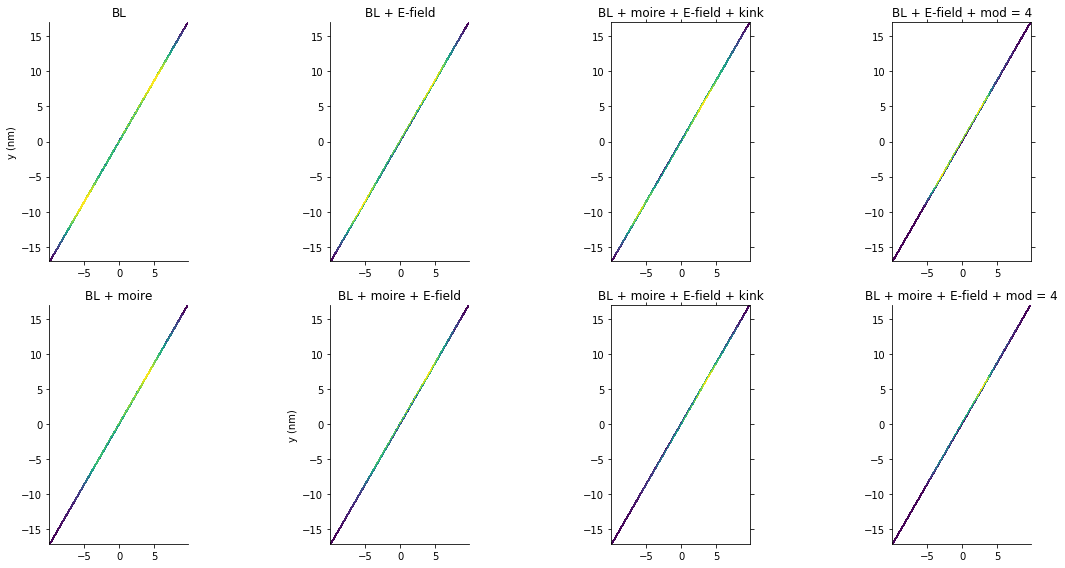

In [12]:
eField = 0.1
cellSize = 40
nMoire = 4
nMoireX = 1
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.2

model = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire1D_Z(3,epsilon,Cx),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    moire1D_Z(3,epsilon,Cx)
    
)

model4 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(-1,4),
    moire1D_Z(3,epsilon,Cx),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

leftK = 0
rightK = 2*np.pi/graphene.a
yMin = -0.3
yMax = 0.3
xMin = 7
xMax = rightK/2
stepK = 0.05

dataDir = dataDirRoot + "SinusPot/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


size = len(model.hamiltonian.todense())
bandNr = int(size/2+1)
print(bandNr)

plt.subplot(241)
solver = pb.solver.lapack(model)
eField = 0
Hx = "noMoire"
modFactor = 1
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot_contourf(num_periods=10)
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.lapack(model0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver0, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot_contourf(num_periods=10)
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.lapack(model1)
eField = 0
Hx = "HZ"
modFactor = 1
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver1, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot_contourf(num_periods=10)
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.lapack(model2)
eField = 0.1
Hx = "HZ"
modFactor = 1
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver2, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot_contourf(num_periods=10)
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.lapack(model3)
eField = 0.1
Hx = "HZ"
modFactor = 4
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver3, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot_contourf(num_periods=10)
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.lapack(model4)
eField = 0.1
Hx = "noMoire"
modFactor = 4
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver4, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot_contourf(num_periods=10)
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.lapack(model5)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1"
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver5, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot_contourf(num_periods=10)
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.lapack(model6)
eField = 0.1
Hx = "HZ"
modFactor = "Min1"
fname = makeName3(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr)
prob = calc_prob_s(solver6, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK, bandNr )
prob.plot_contourf(num_periods=10)
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout()

Bands_E_0_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_1_Ks_0_25.55_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_1_Ks_0_25.55_stepK_0.01  exists.
Bands_E_0_CS_40_nMx_1_nMy_4_HZ_0.2_modF_1_Ks_0_25.55_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_HZ_0.2_modF_1_Ks_0_25.55_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_HZ_0.2_modF_4_Ks_0_25.55_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_4_Ks_0_25.55_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_noMoire_0.2_modF_Min1_Ks_0_25.55_stepK_0.01  exists.
Bands_E_0.1_CS_40_nMx_1_nMy_4_HZ_0.2_modF_Min1_Ks_0_25.55_stepK_0.01  exists.


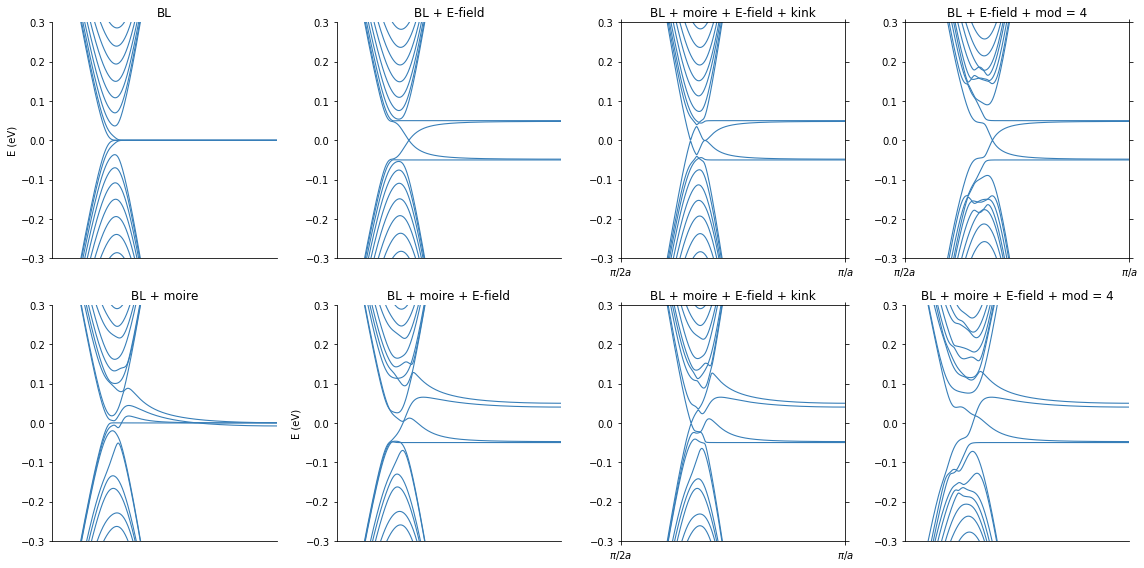

In [7]:
eField = 0.1
cellSize = 40
nMoire = 7
nMoireX = 1
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.2

model = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire1D_Z(3,epsilon,Cx),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    moire1D_Z(3,epsilon,Cx)
    
)

model4 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=True, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(-1,4),
    moire1D_Z(3,epsilon,Cx),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

leftK = 0
rightK = 2*np.pi/graphene.a
yMin = -0.3
yMax = 0.3
xMin = 7
xMax = rightK/2
stepK = 0.01

dataDir = dataDirRoot + "SinusPot/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)
solver = pb.solver.lapack(model)
eField = 0
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.lapack(model0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver0, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.lapack(model1)
eField = 0
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver1, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.lapack(model2)
eField = 0.1
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver2, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.lapack(model3)
eField = 0.1
Hx = "HZ"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver3, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx,modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.lapack(model4)
eField = 0.1
Hx = "noMoire"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver4, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.lapack(model5)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver5, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.lapack(model6)
eField = 0.1
Hx = "HZ"
modFactor = "Min1"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver6, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout() 

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("SinusCellSize40_Finer_moire7.png", dpi=400)

# moire potential : cell size 10

Bands_E_0_CS_10_nMx_1_nMy_4_noMoire_0.3_modF_1_Ks_-0.7374630642229563_0.74_stepK_0.05  exists.
Bands_E_0.1_CS_10_nMx_1_nMy_4_noMoire_0.3_modF_1_Ks_-0.7374630642229563_0.74_stepK_0.05  exists.
Bands_E_0_CS_10_nMx_1_nMy_4_HZ_0.3_modF_1_Ks_-0.7374630642229563_0.74_stepK_0.05  exists.
Bands_E_0.1_CS_10_nMx_1_nMy_4_HZ_0.3_modF_1_Ks_-0.7374630642229563_0.74_stepK_0.05  exists.
Bands_E_0.1_CS_10_nMx_1_nMy_4_HZ_0.3_modF_4_Ks_-0.7374630642229563_0.74_stepK_0.05  exists.
Bands_E_0.1_CS_10_nMx_1_nMy_4_noMoire_0.3_modF_4_Ks_-0.7374630642229563_0.74_stepK_0.05  exists.
Bands_E_0.1_CS_10_nMx_1_nMy_4_noMoire_0.3_modF_Min1Bis_Ks_-0.7374630642229563_0.74_stepK_0.05  exists.
Bands_E_0.1_CS_10_nMx_1_nMy_4_HZ_0.3_modF_Min1Bis_Ks_-0.7374630642229563_0.74_stepK_0.05  exists.


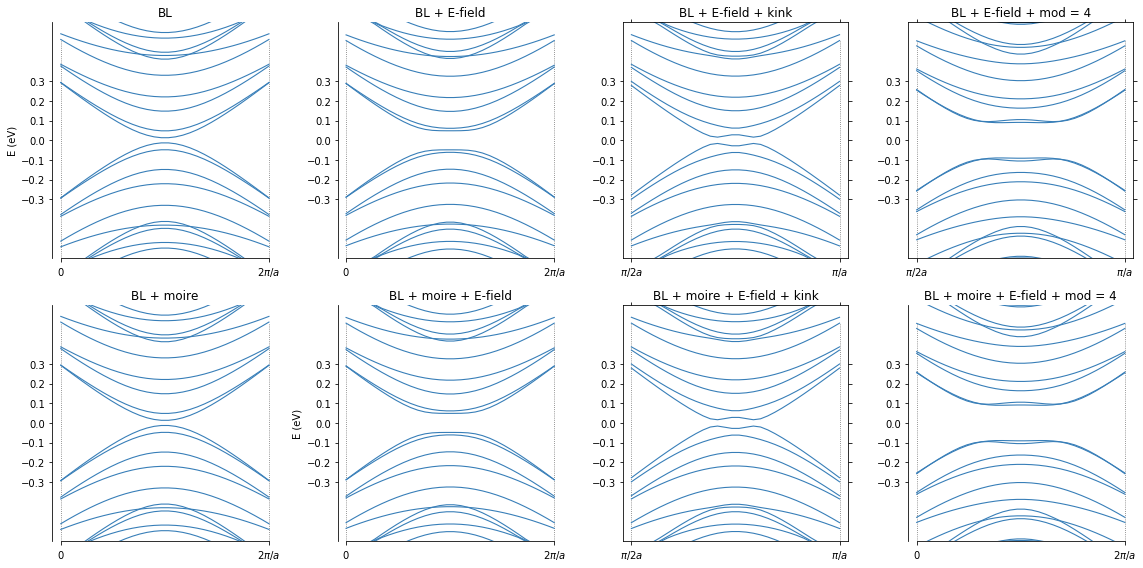

In [10]:
eField = 0.1
cellSize = 10
nMoire = 4
nMoireX = 1
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.3

model = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

#model = pb.Model(
#    bilayer_graphene_armchair(),
#    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
#    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
#    #pb.translational_symmetry(a1=True, a2=False),
#    #electric_field(0.2),
#    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
#    #moire_modulate(2)
#)

model0 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx)
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    
)

model4 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

#leftK = 0/cellSize
#rightK = 2*np.pi/graphene.a/cellSize
#yMin = -0.3
#yMax = 0.3
#xMin = 7
#xMax = rightK/2
#stepK = 0.05




#leftK = -np.pi/(3*ac)/cellSize
#rightK = np.pi/(3*ac)/cellSize
#
#yMin = -0.6
#yMax = 0.6
#xMin = leftK
#xMax = rightK
#stepK = 0.005







leftK = -np.pi/(3*ac)/cellSize
rightK = np.pi/(3*ac)/cellSize

yMin = -0.6
yMax = 0.6
xMin = leftK
xMax = rightK
stepK = 0.05

dataDir = dataDirRoot + "moireSC10Armchair/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


#plt.subplot(241)
#solver = pb.solver.arpack(model, k=200, sigma=0)
#eField = 0
#Hx = "noMoire"
#modFactor = 1
#fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
#bands = calc_bands_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
#bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
#plt.ylim(yMin,yMax)
##plt.xlim(xMin,xMax)
#plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.title("BL")
#plt.xlabel("")


plt.subplot(241)
solver = pb.solver.lapack(model)
eField = 0
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.lapack(model0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver0, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.lapack(model1)
eField = 0
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver1, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.lapack(model2)
eField = 0.1
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver2, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.lapack(model3)
eField = 0.1
Hx = "HZ"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver3, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx,modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.lapack(model4)
eField = 0.1
Hx = "noMoire"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver4, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.lapack(model5)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver5, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.lapack(model6)
eField = 0.1
Hx = "HZ"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver6, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout() 

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("MoireCellSize10Armchair.png", dpi=400)

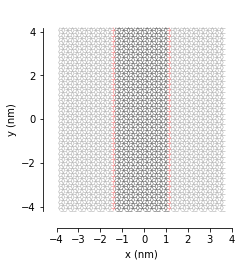

In [8]:
model.plot(num_periods=1)

Bands_E_0_CS_20_nMx_1_nMy_4_noMoire_0.3_modF_1_Ks_0.0_1.28_stepK_0.05  exists.
Bands_E_0.1_CS_20_nMx_1_nMy_4_noMoire_0.3_modF_1_Ks_0.0_1.28_stepK_0.05  exists.
Bands_E_0_CS_20_nMx_1_nMy_4_HZ_0.3_modF_1_Ks_0.0_1.28_stepK_0.05  exists.
Bands_E_0.1_CS_20_nMx_1_nMy_4_HZ_0.3_modF_1_Ks_0.0_1.28_stepK_0.05  exists.
Bands_E_0.1_CS_20_nMx_1_nMy_4_HZ_0.3_modF_4_Ks_0.0_1.28_stepK_0.05  exists.
Bands_E_0.1_CS_20_nMx_1_nMy_4_noMoire_0.3_modF_4_Ks_0.0_1.28_stepK_0.05  exists.
Bands_E_0.1_CS_20_nMx_1_nMy_4_noMoire_0.3_modF_Min1_Ks_0.0_1.28_stepK_0.05  exists.
Bands_E_0.1_CS_20_nMx_1_nMy_4_HZ_0.3_modF_Min1_Ks_0.0_1.28_stepK_0.05  exists.


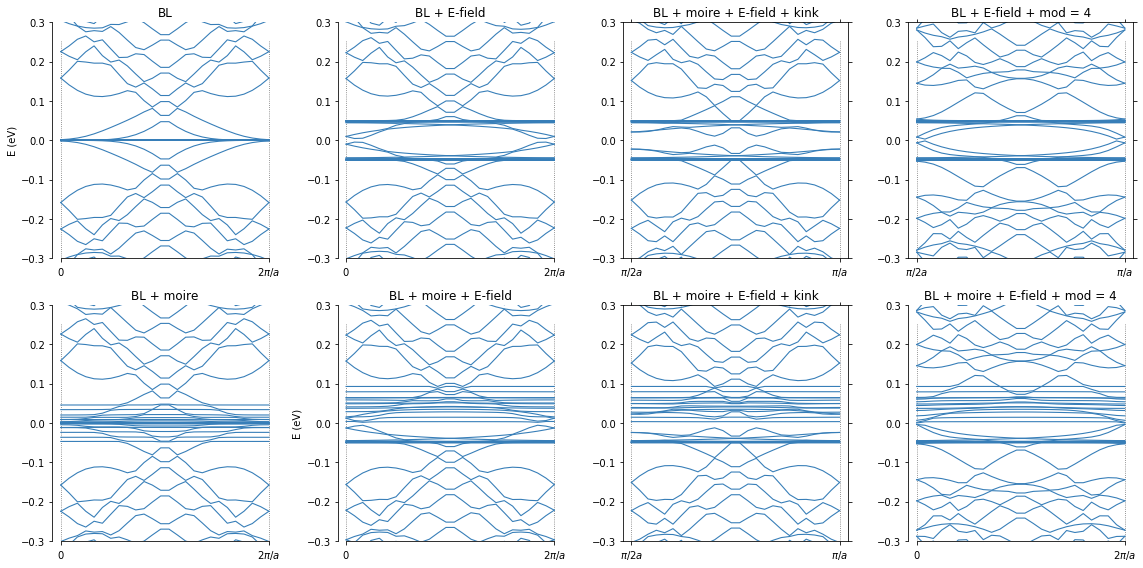

In [9]:
eField = 0.1
cellSize = 20
nMoire = 4
nMoireX = 1
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.3

model = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx)
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    
)

model4 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(-1,4),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

leftK = 0/cellSize
rightK = 2*np.pi/graphene.a/cellSize
yMin = -0.3
yMax = 0.3
xMin = 7
xMax = rightK/2
stepK = 0.05

dataDir = dataDirRoot + "moireSC10/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)
solver = pb.solver.lapack(model)
eField = 0
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.lapack(model0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver0, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.lapack(model1)
eField = 0
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver1, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.lapack(model2)
eField = 0.1
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver2, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.lapack(model3)
eField = 0.1
Hx = "HZ"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver3, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx,modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.lapack(model4)
eField = 0.1
Hx = "noMoire"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver4, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.lapack(model5)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver5, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.lapack(model6)
eField = 0.1
Hx = "HZ"
modFactor = "Min1"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver6, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout() 

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("MoireCellSize20.png", dpi=400)

In [ ]:
eField = 0.1
cellSize = 30
nMoire = 4
nMoireX = 1
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.3

model = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx)
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    
)

model4 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(-1,4),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

leftK = 0/cellSize
rightK = 2*np.pi/graphene.a/cellSize
yMin = -0.3
yMax = 0.3
xMin = 7
xMax = rightK/2
stepK = 0.05

dataDir = dataDirRoot + "moireSC10/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)
solver = pb.solver.lapack(model)
eField = 0
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.lapack(model0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver0, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.lapack(model1)
eField = 0
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver1, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.lapack(model2)
eField = 0.1
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver2, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.lapack(model3)
eField = 0.1
Hx = "HZ"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver3, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx,modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.lapack(model4)
eField = 0.1
Hx = "noMoire"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver4, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.lapack(model5)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver5, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.lapack(model6)
eField = 0.1
Hx = "HZ"
modFactor = "Min1"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver6, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"])
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout() 

Bands_E_0_CS_30_nMx_1_nMy_4_noMoire_0.3_modF_1_Ks_-0.24582102140765208_0.25_stepK_0.005  exists.
Bands_E_0.1_CS_30_nMx_1_nMy_4_noMoire_0.3_modF_1_Ks_-0.24582102140765208_0.25_stepK_0.005  exists.
Bands_E_0_CS_30_nMx_1_nMy_4_HZ_0.3_modF_1_Ks_-0.24582102140765208_0.25_stepK_0.005  exists.
Bands_E_0.1_CS_30_nMx_1_nMy_4_HZ_0.3_modF_1_Ks_-0.24582102140765208_0.25_stepK_0.005  exists.
Bands_E_0.1_CS_30_nMx_1_nMy_4_HZ_0.3_modF_4_Ks_-0.24582102140765208_0.25_stepK_0.005  exists.
Bands_E_0.1_CS_30_nMx_1_nMy_4_noMoire_0.3_modF_4_Ks_-0.24582102140765208_0.25_stepK_0.005  exists.
Bands_E_0.1_CS_30_nMx_1_nMy_4_noMoire_0.3_modF_Min1Bis_Ks_-0.24582102140765208_0.25_stepK_0.005  exists.
Bands_E_0.1_CS_30_nMx_1_nMy_4_HZ_0.3_modF_Min1Bis_Ks_-0.24582102140765208_0.25_stepK_0.005  exists.


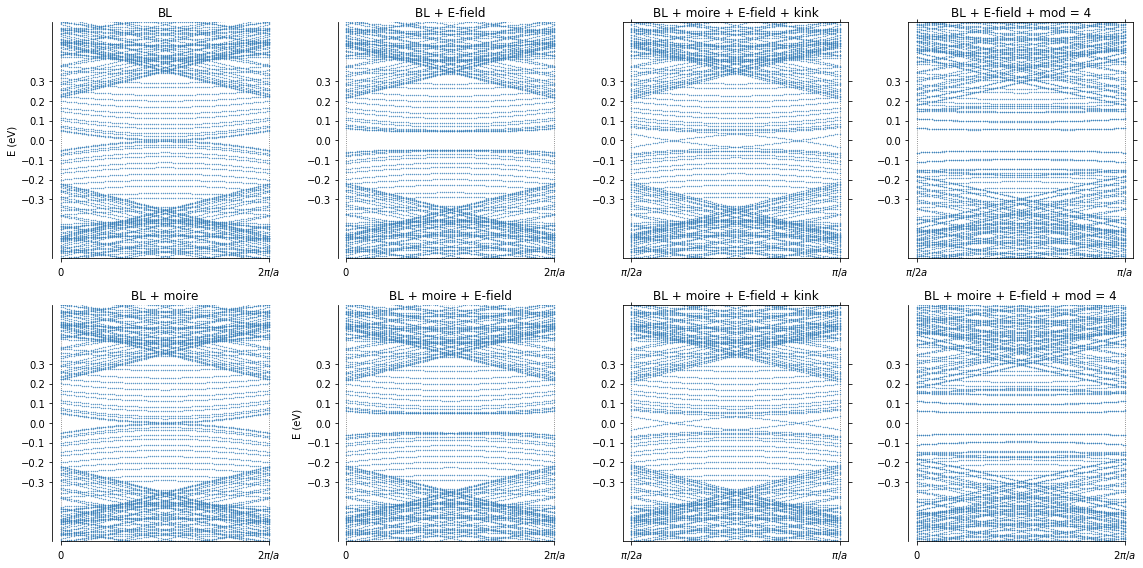

In [25]:
eField = 0.1
cellSize = 30
nMoire = 4
nMoireX = 1
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.3

model = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx)
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    
)

model4 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

#leftK = 0/cellSize
#rightK = 2*np.pi/graphene.a/cellSize
#yMin = -0.3
#yMax = 0.3
#xMin = 7
#xMax = rightK/2
#stepK = 0.005

leftK = -np.pi/(3*ac)/cellSize
rightK = np.pi/(3*ac)/cellSize

yMin = -0.6
yMax = 0.6
xMin = leftK
xMax = rightK
stepK = 0.005

dataDir = dataDirRoot + "moireSC30Armchair/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)
solver = pb.solver.arpack(model, k=200, sigma=0)
eField = 0
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.arpack(model0, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver0, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.arpack(model1, k=200, sigma=0)
eField = 0
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver1, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.arpack(model2, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver2, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.arpack(model3, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver3, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx,modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.arpack(model4, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver4, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.arpack(model5, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver5, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.arpack(model6, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver6, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout() 

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("MoireCellSize30Armchair.png", dpi=400)

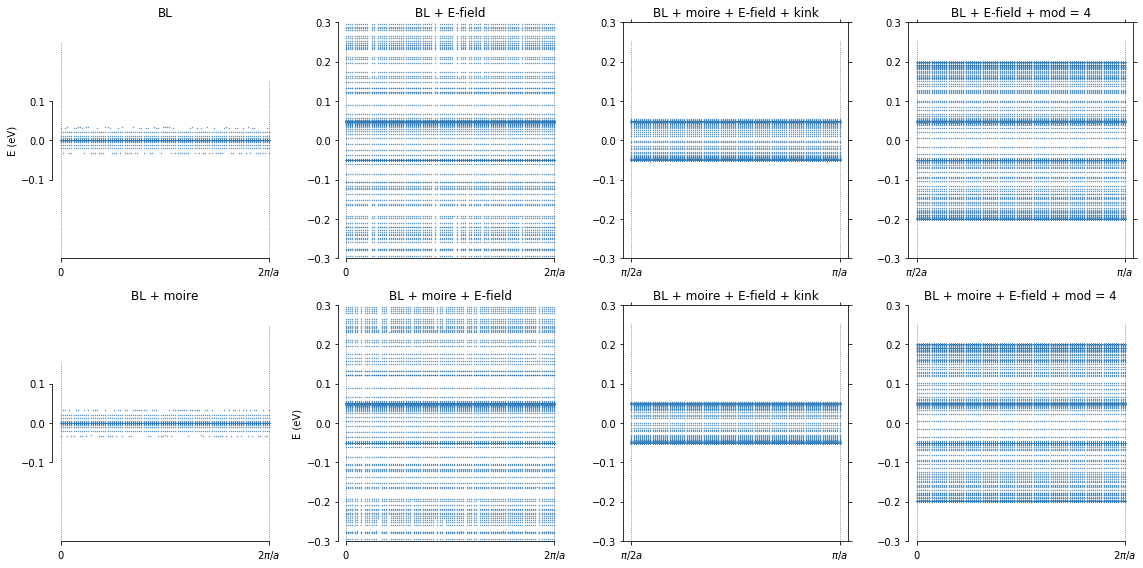

In [27]:
eField = 0.1
cellSize = 30
nMoire = 4
nMoireX = 1
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.3

model = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx)
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    
)

model4 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

#leftK = 0/cellSize
#rightK = 2*np.pi/graphene.a/cellSize
#yMin = -0.3
#yMax = 0.3
#xMin = 7
#xMax = rightK/2
#stepK = 0.005

leftK = -np.pi/(3*ac)/cellSize
rightK = np.pi/(3*ac)/cellSize

yMin = -0.3
yMax = 0.3
xMin = leftK
xMax = rightK
stepK = 0.005

dataDir = dataDirRoot + "moireSC30ArmchairBis/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)
solver = pb.solver.arpack(model, k=200, sigma=0)
eField = 0
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.arpack(model0, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver0, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.arpack(model1, k=200, sigma=0)
eField = 0
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver1, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.arpack(model2, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver2, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.arpack(model3, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver3, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx,modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.arpack(model4, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver4, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.arpack(model5, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver5, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.arpack(model6, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver6, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout() 

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("MoireCellSize30ArmchairBis.png", dpi=400)

Bands_E_0_CS_30_nMx_1_nMy_4_noMoire_0.3_modF_1_Ks_0.0_0.85_stepK_0.005  exists.
Bands_E_0.1_CS_30_nMx_1_nMy_4_noMoire_0.3_modF_1_Ks_0.0_0.85_stepK_0.005  exists.
Bands_E_0_CS_30_nMx_1_nMy_4_HZ_0.3_modF_1_Ks_0.0_0.85_stepK_0.005  exists.
Bands_E_0.1_CS_30_nMx_1_nMy_4_HZ_0.3_modF_1_Ks_0.0_0.85_stepK_0.005  exists.
Bands_E_0.1_CS_30_nMx_1_nMy_4_noMoire_0.3_modF_Min1Bis_Ks_0.0_0.85_stepK_0.005  exists.
Bands_E_0.1_CS_30_nMx_1_nMy_4_HZ_0.3_modF_Min1Bis_Ks_0.0_0.85_stepK_0.005  exists.


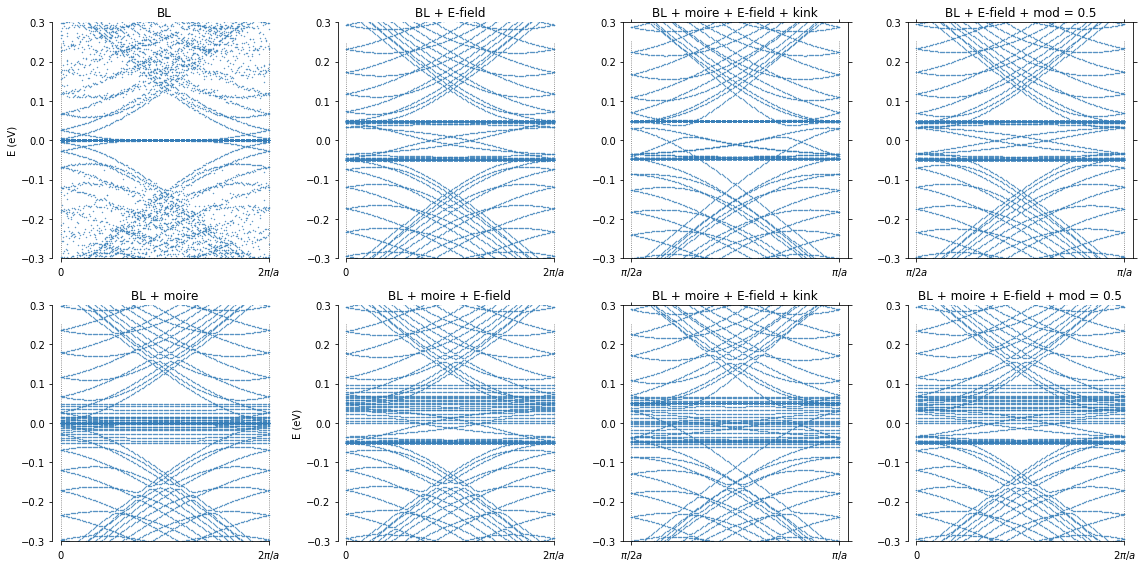

In [25]:
eField = 0.1
cellSize = 30
nMoire = 4
nMoireX = 1
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.3

model = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(0.5,nMoire),
    #moire1D_Z(3,epsilon,Cx)
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    
)

model4 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(0.5,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

leftK = 0/cellSize
rightK = 2*np.pi/graphene.a/cellSize
yMin = -0.3
yMax = 0.3
xMin = 7
xMax = rightK/2
stepK = 0.005

dataDir = dataDirRoot + "moireSC30/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)
solver = pb.solver.arpack(model, k=200, sigma=0)
eField = 0
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.arpack(model0, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver0, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.arpack(model1, k=200, sigma=0)
eField = 0
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver1, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.arpack(model2, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver2, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.arpack(model3, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = 0.5
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver3, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx,modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.arpack(model4, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 0.5
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver4, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.arpack(model5, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver5, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.arpack(model6, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver6, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout() 

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("MoireCellSize30_mod0_5.png", dpi=400)

In [ ]:
eField = 0.1
cellSize = 30
nMoire = 4
nMoireX = 1
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "H0"
Cx = 0.3

model = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx)
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    
)

model4 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoire*cellSize*graphene.a,nMoire*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

leftK = 0/cellSize
rightK = 2*np.pi/graphene.a/cellSize
yMin = -0.3
yMax = 0.3
xMin = 7
xMax = rightK/2
stepK = 0.005

dataDir = dataDirRoot + "moireSC30/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)
solver = pb.solver.arpack(model, k=200, sigma=0)
eField = 0
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.arpack(model0, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver0, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.arpack(model1, k=200, sigma=0)
eField = 0
Hx = "H0"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver1, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.arpack(model2, k=200, sigma=0)
eField = 0.1
Hx = "H0"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver2, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.arpack(model3, k=200, sigma=0)
eField = 0.1
Hx = "H0"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver3, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx,modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.arpack(model4, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver4, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.arpack(model5, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver5, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.arpack(model6, k=200, sigma=0)
eField = 0.1
Hx = "H0"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver6, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout() 

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("MoireCellSize30_H0.png", dpi=400)

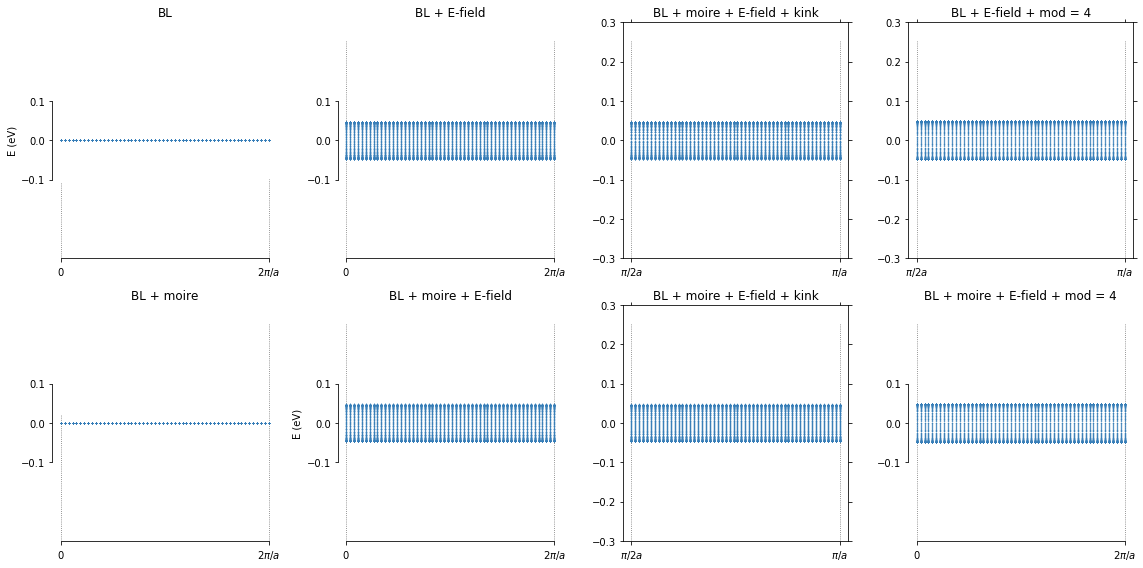

In [26]:
eField = 0.1
cellSize = 55
nMoire = 4
nMoireX = 1
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.3

model = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx)
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    
)

model4 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene_armchair(),
    pb.rectangle(cellSize*3*ac,nMoire*cellSize*graphene.a),  # nm
    pb.translational_symmetry(a1=3*ac*cellSize, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

#leftK = 0/cellSize
#rightK = 2*np.pi/graphene.a/cellSize
#yMin = -0.3
#yMax = 0.3
#xMin = 7
#xMax = rightK/2
#stepK = 0.005

leftK = -np.pi/(3*ac)/cellSize
rightK = np.pi/(3*ac)/cellSize

yMin = -0.3
yMax = 0.3
xMin = leftK
xMax = rightK
stepK = 0.005

dataDir = dataDirRoot + "moireSC55Armchair/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)
solver = pb.solver.arpack(model, k=200, sigma=0)
eField = 0
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.arpack(model0, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver0, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.arpack(model1, k=200, sigma=0)
eField = 0
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver1, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.arpack(model2, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = 1
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver2, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.arpack(model3, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver3, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx,modFactor, leftK, rightK , stepK)
bands.plot(point_labels=[r"$0$", r"$2 \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.arpack(model4, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 4
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver4, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.arpack(model5, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver5, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.arpack(model6, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = "Min1Bis"
fname = makeName2(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
bands = calc_bands_s(solver6, dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK )
bands.plot(point_labels=[r"$\pi / 2a$", r"$ \pi / a$"],linestyle="None",marker=".",markersize=0.8)
plt.ylim(yMin,yMax)
#plt.xlim(xMin,xMax)
plt.yticks([-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3])
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout() 

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("MoireCellSize55Armchair.png", dpi=400)

In [32]:
print(bands.data)

AttributeError: 'Bands' object has no attribute 'data'

Quick KPM calculation for ZIGZAG

Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:21 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:19 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:23 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:20 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:21 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:20 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:21 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:20 / ETA: 0:00:00


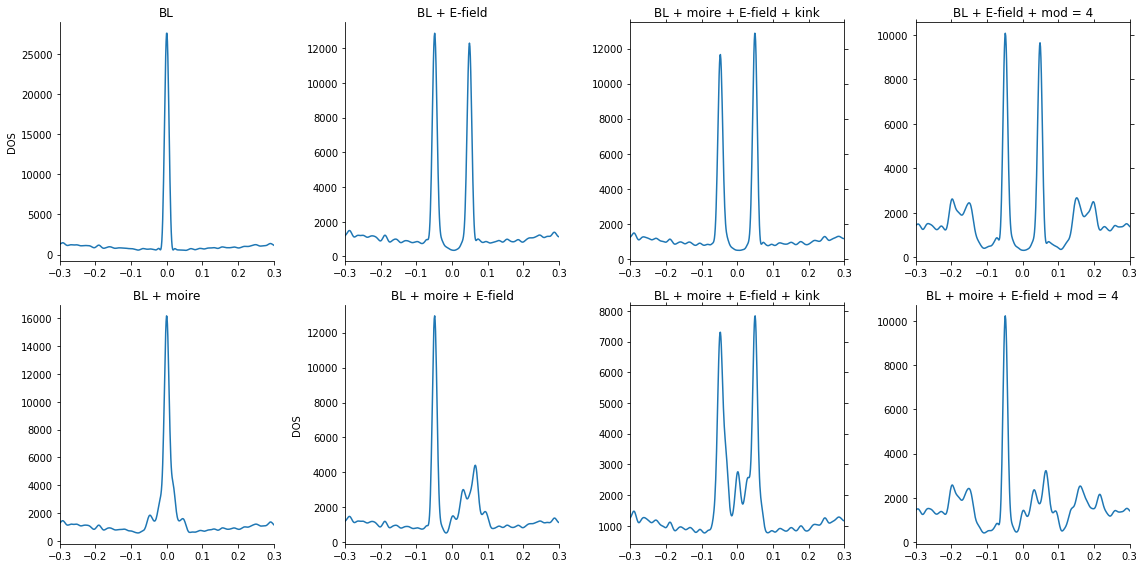

In [17]:
eField = 0.1
cellSize = 55
nMoire = 4
nMoireX = 5
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.3

model = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx)
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    
)

model4 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

leftK = 0/cellSize
rightK = 2*np.pi/graphene.a/cellSize
yMin = -0.3
yMax = 0.3
xMin = 7
xMax = rightK/2
stepK = 0.005

dataDir = dataDirRoot + "moireSC55/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)

eField = 0
Hx = "noMoire"
modFactor = 1
kpm = pb.kpm(model)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.arpack(model0, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
kpm = pb.kpm(model0)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.arpack(model1, k=200, sigma=0)
eField = 0
Hx = "HZ"
modFactor = 1
kpm = pb.kpm(model1)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.arpack(model2, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = 1
kpm = pb.kpm(model2)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.arpack(model3, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = 4
kpm = pb.kpm(model3)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.arpack(model4, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 4
kpm = pb.kpm(model4)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.arpack(model5, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1Bis"
kpm = pb.kpm(model5)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.arpack(model6, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = "Min1Bis"
kpm = pb.kpm(model6)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout() 

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("DOS_MoireCellSize55.png", dpi=400)

Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:46 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:43 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:43 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:43 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:44 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:44 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:44 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:43 / ETA: 0:00:00


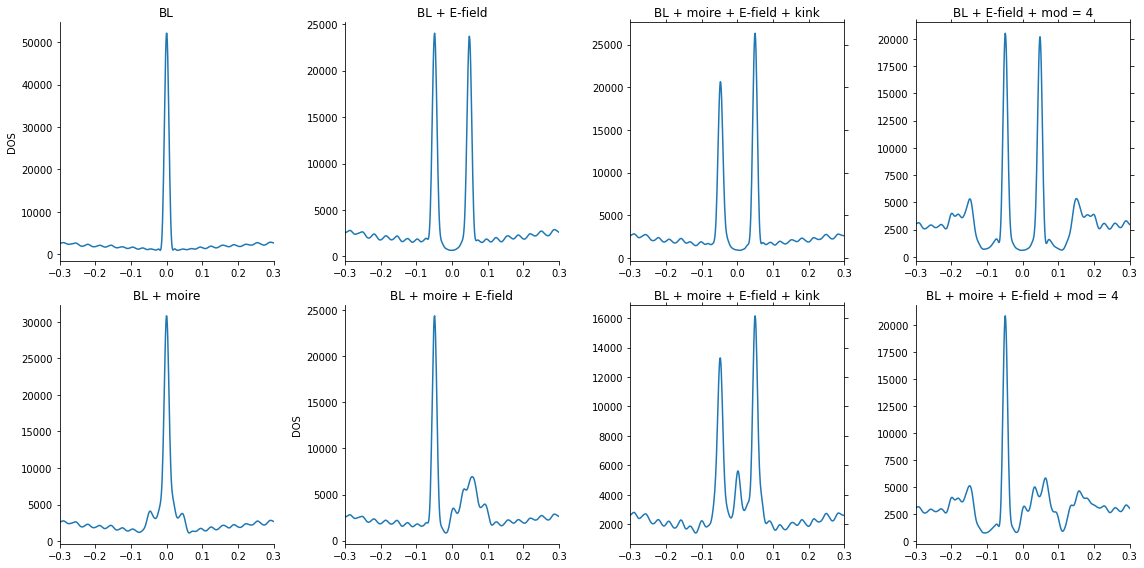

In [16]:
eField = 0.1
cellSize = 55
nMoire = 4
nMoireX = 10
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.3

model = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx)
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    
)

model4 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

leftK = 0/cellSize
rightK = 2*np.pi/graphene.a/cellSize
yMin = -0.3
yMax = 0.3
xMin = 7
xMax = rightK/2
stepK = 0.005

dataDir = dataDirRoot + "moireSC55/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)

eField = 0
Hx = "noMoire"
modFactor = 1
kpm = pb.kpm(model)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.arpack(model0, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
kpm = pb.kpm(model0)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.arpack(model1, k=200, sigma=0)
eField = 0
Hx = "HZ"
modFactor = 1
kpm = pb.kpm(model1)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.arpack(model2, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = 1
kpm = pb.kpm(model2)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.arpack(model3, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = 4
kpm = pb.kpm(model3)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.arpack(model4, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 4
kpm = pb.kpm(model4)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.arpack(model5, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1Bis"
kpm = pb.kpm(model5)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.arpack(model6, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = "Min1Bis"
kpm = pb.kpm(model6)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout() 

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("DOS_MoireCellSize55.png", dpi=400)

DOS_E_0_CS_55_nMx_10_nMy_4_noMoire_0.3_modF_1_Ks_0.0_0.46_stepK_0.005  exists.
DOS_E_0.1_CS_55_nMx_10_nMy_4_noMoire_0.3_modF_1_Ks_0.0_0.46_stepK_0.005  exists.
DOS_E_0_CS_55_nMx_10_nMy_4_HZ_0.3_modF_1_Ks_0.0_0.46_stepK_0.005  exists.
DOS_E_0.1_CS_55_nMx_10_nMy_4_HZ_0.3_modF_1_Ks_0.0_0.46_stepK_0.005  exists.
DOS_E_0.1_CS_55_nMx_10_nMy_4_HZ_0.3_modF_0.5_Ks_0.0_0.46_stepK_0.005  exists.
DOS_E_0.1_CS_55_nMx_10_nMy_4_noMoire_0.3_modF_0.5_Ks_0.0_0.46_stepK_0.005  exists.
DOS_E_0.1_CS_55_nMx_10_nMy_4_noMoire_0.3_modF_Min1Bis_Ks_0.0_0.46_stepK_0.005  exists.
DOS_E_0.1_CS_55_nMx_10_nMy_4_HZ_0.3_modF_Min1Bis_Ks_0.0_0.46_stepK_0.005  exists.


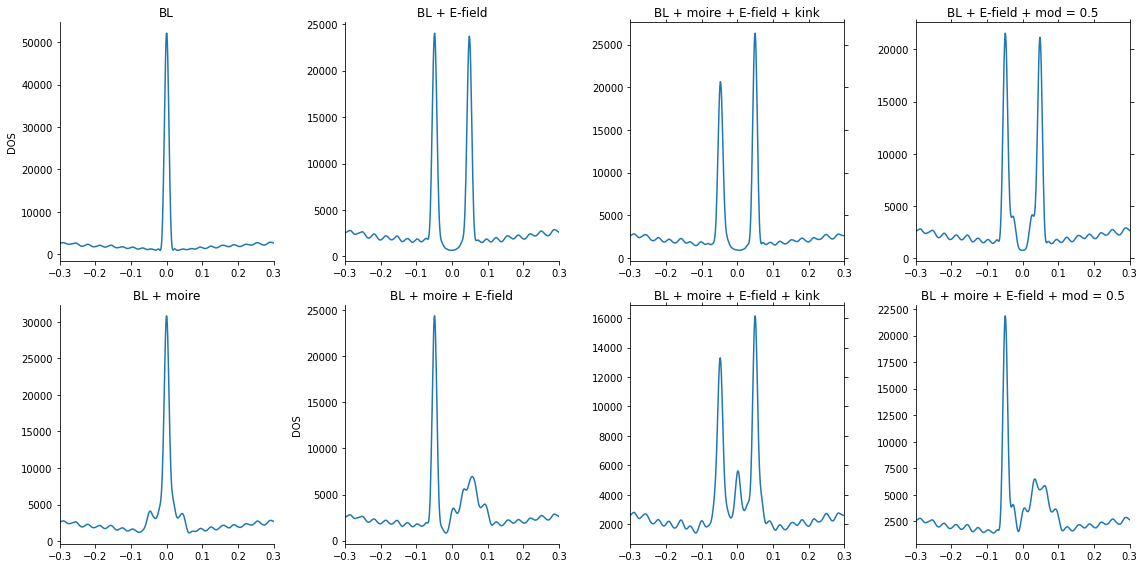

In [28]:
eField = 0.1
cellSize = 55
nMoire = 4
nMoireX = 10
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.3

model = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(0.5,nMoire),
    #moire1D_Z(3,epsilon,Cx)
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    
)

model4 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(0.5,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

leftK = 0/cellSize
rightK = 2*np.pi/graphene.a/cellSize
yMin = -0.3
yMax = 0.3
xMin = 7
xMax = rightK/2
stepK = 0.005

dataDir = dataDirRoot + "moireSC55/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)

eField = 0
Hx = "noMoire"
modFactor = 1
kpm = pb.kpm(model)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.arpack(model0, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
kpm = pb.kpm(model0)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.arpack(model1, k=200, sigma=0)
eField = 0
Hx = "HZ"
modFactor = 1
kpm = pb.kpm(model1)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.arpack(model2, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = 1
kpm = pb.kpm(model2)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.arpack(model3, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = 0.5
kpm = pb.kpm(model3)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.arpack(model4, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 0.5
kpm = pb.kpm(model4)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.arpack(model5, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1Bis"
kpm = pb.kpm(model5)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.arpack(model6, k=200, sigma=0)
eField = 0.1
Hx = "HZ"
modFactor = "Min1Bis"
kpm = pb.kpm(model6)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout() 

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("DOS_MoireCellSize55_Mod0_05.png", dpi=400)

In [31]:
print(dos.data)

[ 2617.33569336  2642.21972656  2670.01269531  2700.00976562
  2730.65136719  2759.95214844  2785.51391602  2804.64624023
  2814.78857422  2814.15527344  2801.44384766  2776.55932617
  2740.71337891  2695.85717773  2645.04101562  2591.84985352
  2540.10400391  2493.38452148  2454.65063477  2426.11279297
  2409.05175781  2403.50854492  2408.67895508  2423.17211914
  2444.95849609  2471.96606445  2502.0546875   2533.7253418
  2565.3605957   2596.01196289  2624.92333984  2651.27368164
  2674.41040039  2693.23461914  2706.68554688  2713.05322266
  2711.06958008  2699.23168945  2676.74951172  2643.31494141
  2599.55517578  2546.94067383  2487.57226562  2424.27075195
  2360.04785156  2297.8527832   2240.07958984  2188.74365234
  2145.05517578  2109.48291016  2082.07617188  2062.43261719
  2050.35766602  2045.45507812  2047.68786621  2056.95043945
  2073.31689453  2096.74072266  2126.08422852  2160.36987305
  2197.36035156  2234.60546875  2269.0324707   2297.4074707
  2316.98632812  2325.4960

DOS_E_0_CS_55_nMx_10_nMy_4_noMoire_0.3_modF_1_Ks_0.0_0.46_stepK_0.005  exists.
DOS_E_0.1_CS_55_nMx_10_nMy_4_noMoire_0.3_modF_1_Ks_0.0_0.46_stepK_0.005  exists.
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:44 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:46 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:45 / ETA: 0:00:00
DOS_E_0.1_CS_55_nMx_10_nMy_4_noMoire_0.3_modF_4_Ks_0.0_0.46_stepK_0.005  exists.
DOS_E_0.1_CS_55_nMx_10_nMy_4_noMoire_0.3_modF_Min1Bis_Ks_0.0_0.46_stepK_0.005  exists.
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:45 / ETA: 0:00:00


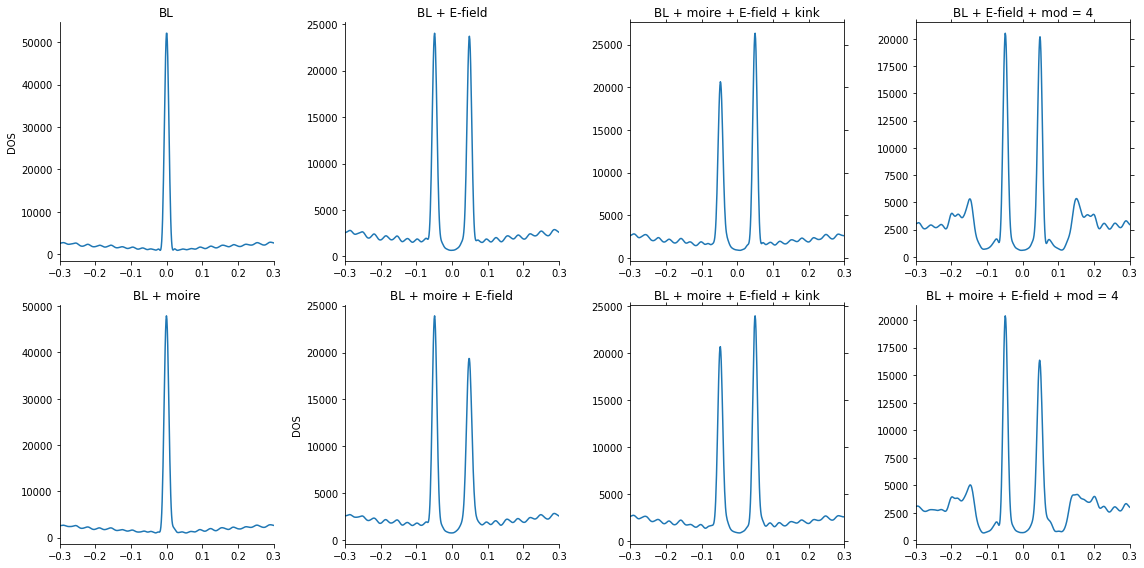

In [21]:
eField = 0.1
cellSize = 55
nMoire = 4
nMoireX = 10
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "H0"
Cx = 0.3

model = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    moire_pattern_Jeil_H0(C0, phi0, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_H0(C0, phi0, epsilon),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx)
    moire_pattern_Jeil_H0(C0, phi0, epsilon),
    
)

model4 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_H0(C0, phi0, epsilon),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

leftK = 0/cellSize
rightK = 2*np.pi/graphene.a/cellSize
yMin = -0.3
yMax = 0.3
xMin = 7
xMax = rightK/2
stepK = 0.005

dataDir = dataDirRoot + "moireSC55/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)

eField = 0
Hx = "noMoire"
modFactor = 1
kpm = pb.kpm(model)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.arpack(model0, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
kpm = pb.kpm(model0)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.arpack(model1, k=200, sigma=0)
eField = 0
Hx = "H0"
modFactor = 1
kpm = pb.kpm(model1)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.arpack(model2, k=200, sigma=0)
eField = 0.1
Hx = "H0"
modFactor = 1
kpm = pb.kpm(model2)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.arpack(model3, k=200, sigma=0)
eField = 0.1
Hx = "H0"
modFactor = 4
kpm = pb.kpm(model3)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.arpack(model4, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 4
kpm = pb.kpm(model4)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.arpack(model5, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1Bis"
kpm = pb.kpm(model5)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.arpack(model6, k=200, sigma=0)
eField = 0.1
Hx = "H0"
modFactor = "Min1Bis"
kpm = pb.kpm(model6)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout() 

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("DOS_MoireCellSize55_H0.png", dpi=400)

DOS_E_0_CS_55_nMx_10_nMy_4_noMoire_0.3_modF_1_Ks_0.0_0.46_stepK_0.005  exists.
DOS_E_0.1_CS_55_nMx_10_nMy_4_noMoire_0.3_modF_1_Ks_0.0_0.46_stepK_0.005  exists.
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:43 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:35 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:34 / ETA: 0:00:00
DOS_E_0.1_CS_55_nMx_10_nMy_4_noMoire_0.3_modF_4_Ks_0.0_0.46_stepK_0.005  exists.
DOS_E_0.1_CS_55_nMx_10_nMy_4_noMoire_0.3_modF_Min1Bis_Ks_0.0_0.46_stepK_0.005  exists.
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:34 / ETA: 0:00:00


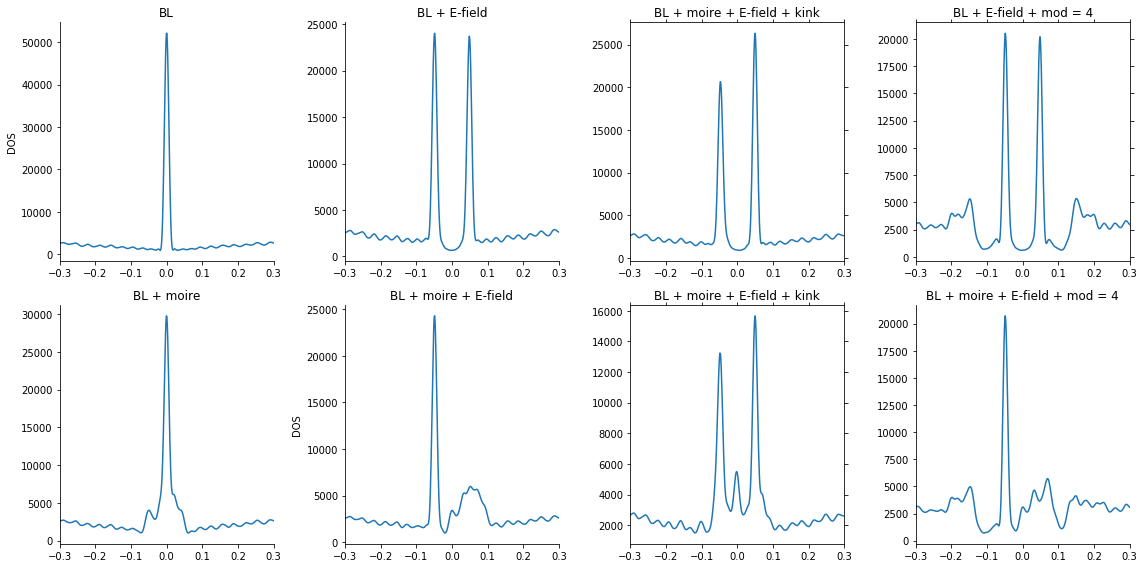

In [22]:
eField = 0.1
cellSize = 55
nMoire = 4
nMoireX = 10
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "H0HZ"
Cx = 0.3

model = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    moire_pattern_Jeil_H0(C0, phi0, epsilon),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_H0(C0, phi0, epsilon),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx)
    moire_pattern_Jeil_H0(C0, phi0, epsilon),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    
)

model4 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_H0(C0, phi0, epsilon),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

leftK = 0/cellSize
rightK = 2*np.pi/graphene.a/cellSize
yMin = -0.3
yMax = 0.3
xMin = 7
xMax = rightK/2
stepK = 0.005

dataDir = dataDirRoot + "moireSC55/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)

eField = 0
Hx = "noMoire"
modFactor = 1
kpm = pb.kpm(model)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.arpack(model0, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 1
kpm = pb.kpm(model0)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.arpack(model1, k=200, sigma=0)
eField = 0
Hx = "H0HZ"
modFactor = 1
kpm = pb.kpm(model1)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.arpack(model2, k=200, sigma=0)
eField = 0.1
Hx = "H0HZ"
modFactor = 1
kpm = pb.kpm(model2)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.arpack(model3, k=200, sigma=0)
eField = 0.1
Hx = "H0HZ"
modFactor = 4
kpm = pb.kpm(model3)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.arpack(model4, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = 4
kpm = pb.kpm(model4)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.arpack(model5, k=200, sigma=0)
eField = 0.1
Hx = "noMoire"
modFactor = "Min1Bis"
kpm = pb.kpm(model5)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.arpack(model6, k=200, sigma=0)
eField = 0.1
Hx = "H0HZ"
modFactor = "Min1Bis"
kpm = pb.kpm(model6)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout() 

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("DOS_MoireCellSize55_H0HZ.png", dpi=400)

DOS_E_0_CS_55_nMx_10_nMy_4_noMoire_0.3_modF_1_Ks_0.0_0.46_stepK_0.005  exists.
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:58 / ETA: 0:00:00
DOS_E_0_CS_55_nMx_10_nMy_4_HZ_0.3_modF_1_Ks_0.0_0.46_stepK_0.005  exists.
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:59 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:59 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:00:57 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:01:02 / ETA: 0:00:00
Computing KPM moments...
Progress 100% [////////////////////////////////] Elapsed: 0:01:18 / ETA: 0:00:00


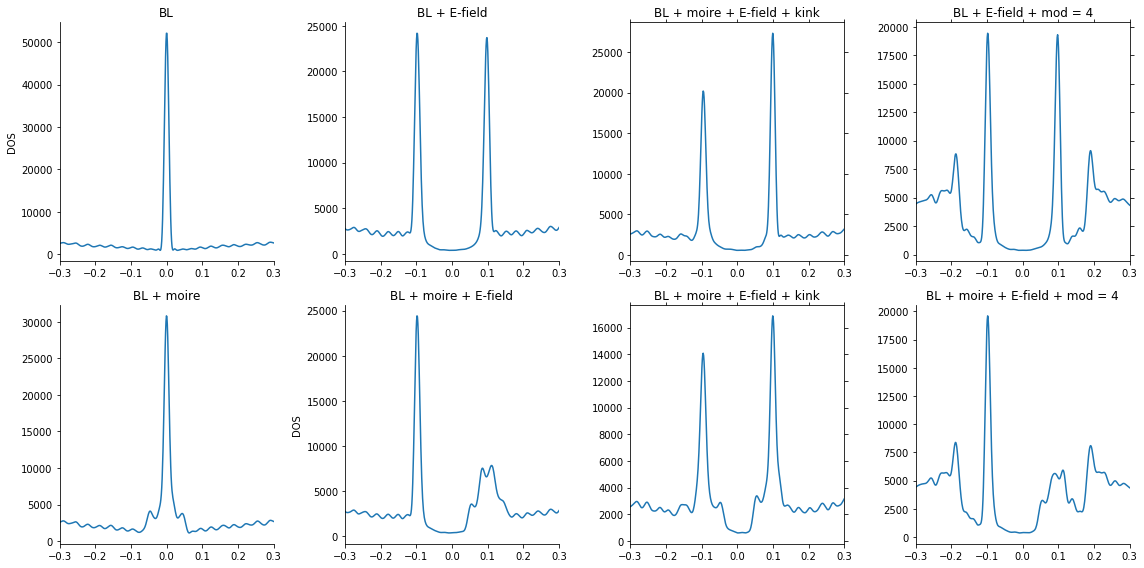

In [19]:
eField = 0.2
cellSize = 55
nMoire = 4
nMoireX = 10
nMoireY = nMoire
epsilon = 1.0/cellSize
C0 = -10.13*0.001
rad = np.pi/180.0
phi0 = 86.53*rad
CZ = -9.01*0.001
phiz = 8.43*rad
Hx = "HZ"
Cx = 0.3

model = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(0.2),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model0 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model1 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    #electric_field(eField),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire1D_Z(3,epsilon,Cx)
    #moire_modulate(2)
)

model2 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    #moire_modulate(2)
)

model3 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx)
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
    
)

model4 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate(4,nMoire),
    #moire1D_Z(3,epsilon,Cx),
)

model5 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
)

model6 = pb.Model(
    bilayer_graphene(),
    pb.rectangle(nMoireX*cellSize*graphene.a,nMoireY*cellSize*graphene.a*np.sin(np.pi/3.0)),  # nm
    pb.translational_symmetry(a1=graphene.a*cellSize*nMoireX, a2=False),
    #pb.translational_symmetry(a1=True, a2=False),
    electric_field(eField),
    moire_modulate_kink(-1,4),
    #moire1D_Z(3,epsilon,Cx),
    moire_pattern_Jeil_HZ(CZ, phiz, epsilon),
)

#f, axes = plt.subplots(1,2)
plt.figure(figsize=(16,8))
#plt.subplot(131)
#model.plot(num_periods=1)
#model.lattice.plot_vectors(position=[-5, 4])  # nm

#plt.show()

leftK = 0/cellSize
rightK = 2*np.pi/graphene.a/cellSize
yMin = -0.3
yMax = 0.3
xMin = 7
xMax = rightK/2
stepK = 0.005

dataDir = dataDirRoot + "moireSC55/"

#gs = gridspec.GridSpec(2, 3)
#f, ((ax00, ax01, ax02),(ax10, ax11, ax12)) = plt.subplots(2, 3)#,sharey='row')
##f3, ((ax0)) = plt.subplots(1, 2,sharey='row')
#
#ax00 = plt.subplot(gs[0])
#ax01 = plt.subplot(gs[1])
#ax02 = plt.subplot(gs[2])
#ax10 = plt.subplot(gs[3])
#ax11 = plt.subplot(gs[4])
#ax12 = plt.subplot(gs[5])


plt.subplot(241)

eField = 0
Hx = "noMoire"
modFactor = 1
kpm = pb.kpm(model)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL")
plt.xlabel("")

plt.subplot(242)
solver0 = pb.solver.arpack(model0, k=200, sigma=0)
eField = 0.2
Hx = "noMoire"
modFactor = 1
kpm = pb.kpm(model0)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + E-field")
plt.xlabel("")
plt.ylabel("")

plt.subplot(245)
solver1 = pb.solver.arpack(model1, k=200, sigma=0)
eField = 0
Hx = "HZ"
modFactor = 1
kpm = pb.kpm(model1)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire")
plt.xlabel("")
plt.ylabel("")

plt.subplot(246)
solver2 = pb.solver.arpack(model2, k=200, sigma=0)
eField = 0.2
Hx = "HZ"
modFactor = 1
kpm = pb.kpm(model2)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field")
plt.xlabel("")

plt.subplot(248)
solver3 = pb.solver.arpack(model3, k=200, sigma=0)
eField = 0.2
Hx = "HZ"
modFactor = 4
kpm = pb.kpm(model3)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field + mod = " + str(modFactor))
plt.xlabel("")
plt.ylabel("")

plt.subplot(244)
solver4 = pb.solver.arpack(model4, k=200, sigma=0)
eField = 0.2
Hx = "noMoire"
modFactor = 4
kpm = pb.kpm(model4)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + E-field + mod = " + str(modFactor))
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(243)
solver5 = pb.solver.arpack(model5, k=200, sigma=0)
eField = 0.2
Hx = "noMoire"
modFactor = "Min1Bis"
kpm = pb.kpm(model5)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")

plt.subplot(247)
solver6 = pb.solver.arpack(model6, k=200, sigma=0)
eField = 0.2
Hx = "HZ"
modFactor = "Min1Bis"
kpm = pb.kpm(model6)
fname = makeName(dataDir, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, leftK, rightK, stepK)
dos = calc_dos_s(dataDir, fname, eField, cellSize, nMoireX, nMoireY, Hx, Cx, modFactor, stepK)
dos.plot()
#plt.xticks([np.pi/graphene.a/2,np.pi/graphene.a])
plt.title("BL + moire + E-field + kink")
pb.pltutils.respine()
plt.xlabel("")
plt.ylabel("")


plt.tight_layout() 

os.chdir("/Users/nihao/Dropbox/Projects/Nicolas/BilayerAndTrilayerRibbons/figDir/")
plt.savefig("DOS_MoireCellSize55_E_0_02.png", dpi=400)